# Notebook 07 — SPICE Validation vs NASA DE440

Compares simulated planetary trajectories against NASA's DE440 ephemeris — the same model used for spacecraft navigation — using the `spiceypy` Python wrapper.

**System:** Solar system (10 bodies), real HORIZONS initial conditions at 2025-01-01  
**Ground truth:** NASA DE440 via SPICE kernels  
**Metric:** Position error in km relative to the Sun over 1 year

> **Note:** SPICE kernels must be downloaded before running this notebook.  
> Run from the project root: `python3 python/download_kernels.py` or see `docs/paper_notes.md`.

In [1]:
import os
if os.path.basename(os.getcwd()) == 'examples':
    os.chdir('..')

In [2]:
import sys
sys.path.insert(0, '.')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import orbit
from python.spice_validate import validate, print_summary

YEAR   = 365.25 * 24 * 3600
SYSTEM = 'systems/solar_system_horizons.json'
EPOCH  = '2025-01-01T00:00:00'

print(f'orbit {orbit.__version__}')
print(f'System: {SYSTEM}')

orbit 2.0.0-dev
System: systems/solar_system_horizons.json


## Run all integrators

In [3]:
print('Running simulations...')

results = {}

results['RK4 (dt=1h)'] = orbit.simulate(
    SYSTEM, steps=8760, dt=3600.0, integrator=orbit.Integrator.RK4)
print('  RK4 done')

results['Leapfrog (dt=1h)'] = orbit.simulate(
    SYSTEM, steps=8760, dt=3600.0, integrator=orbit.Integrator.Leapfrog)
print('  Leapfrog done')

results['RK45 (atol=1e-9)'] = orbit.simulate_adaptive(
    SYSTEM, duration_s=YEAR, dt_initial=3600.0, atol=1e-9, rtol=1e-9)
print('  RK45 (1e-9) done')

results['RK45 (atol=1e-12)'] = orbit.simulate_adaptive(
    SYSTEM, duration_s=YEAR, dt_initial=3600.0, atol=1e-12, rtol=1e-12)
print('  RK45 (1e-12) done')

print('\nComparing against SPICE DE440...')
errors = {label: validate(r, epoch=EPOCH) for label, r in results.items()}
print('Done.')

Running simulations...
  RK4 done
  Leapfrog done


  RK45 (1e-9) done
  RK45 (1e-12) done

Comparing against SPICE DE440...


Done.


## Summary table — Earth position error

In [4]:
print(f"{'Integrator':<24} {'t=0 (km)':>12} {'t=1yr (km)':>12} {'Integration drift (km)':>24}")
print('-' * 76)
for label, err in errors.items():
    e0   = err['Earth'][0]
    e1yr = err['Earth'][-1]
    drift = e1yr - e0
    print(f"{label:<24} {e0:>12,.0f} {e1yr:>12,.0f} {drift:>24,.0f}")

print()
print('Note: t=0 error (~107,000 km) is IC mismatch between HORIZONS and DE440,')
print('not integration error. Integration drift = t=1yr minus t=0.')

Integrator                   t=0 (km)   t=1yr (km)   Integration drift (km)
----------------------------------------------------------------------------
RK4 (dt=1h)                   106,977      165,561                   58,584
Leapfrog (dt=1h)              106,977      165,405                   58,428
RK45 (atol=1e-9)                2,096       56,576                   54,480
RK45 (atol=1e-12)               2,096       56,576                   54,480

Note: t=0 error (~107,000 km) is IC mismatch between HORIZONS and DE440,
not integration error. Integration drift = t=1yr minus t=0.


## Full solar system — RK4 position errors at 1 year

In [5]:
rk4_errors = errors['RK4 (dt=1h)']
print_summary(rk4_errors, results['RK4 (dt=1h)'].snapshots)

earth_pct = rk4_errors['Earth'][-1] / 150e6 * 100
print(f"\nEarth error as % of orbital radius: {earth_pct:.4f}%")


Body           Max error (km)  Mean error (km)  Error at 1yr (km)
------------------------------------------------------------------
Mercury              300572.4         206531.1           202760.5
Venus                194306.1         156260.5           194306.1
Earth                165578.3         134116.1           165561.2
Moon                 168816.1         134127.1           168700.6
Mars                 137807.9          94836.6           137807.9
Jupiter               64571.0          55652.2            64571.0
Saturn                33655.5          21869.7            20421.8
Uranus                24620.5          24396.3            24620.5
Neptune               23888.7          18186.2            23888.7

Earth error as % of orbital radius: 0.1104%


## Earth position error over time — all integrators

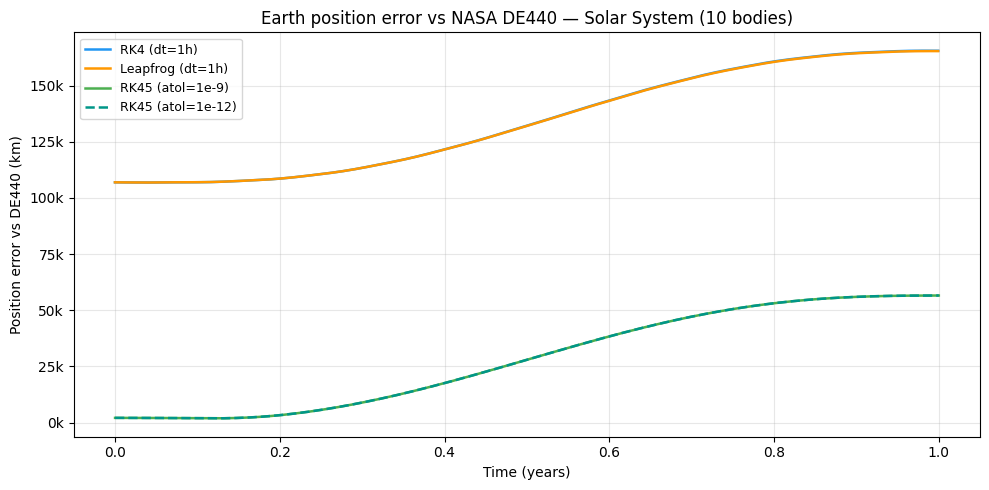

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))

styles = {
    'RK4 (dt=1h)':      {'color': '#2196F3', 'ls': '-'},
    'Leapfrog (dt=1h)': {'color': '#FF9800', 'ls': '-'},
    'RK45 (atol=1e-9)': {'color': '#4CAF50', 'ls': '-'},
    'RK45 (atol=1e-12)':{'color': '#009688', 'ls': '--'},
}

for label, err in errors.items():
    snapshots = results[label].snapshots
    t_yr = np.array([s.time_s for s in snapshots]) / YEAR
    s = styles[label]
    ax.plot(t_yr, err['Earth'], label=label,
            color=s['color'], ls=s['ls'], linewidth=1.8)

ax.set_xlabel('Time (years)')
ax.set_ylabel('Position error vs DE440 (km)')
ax.set_title('Earth position error vs NASA DE440 — Solar System (10 bodies)')
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## All bodies — RK4 position error over time

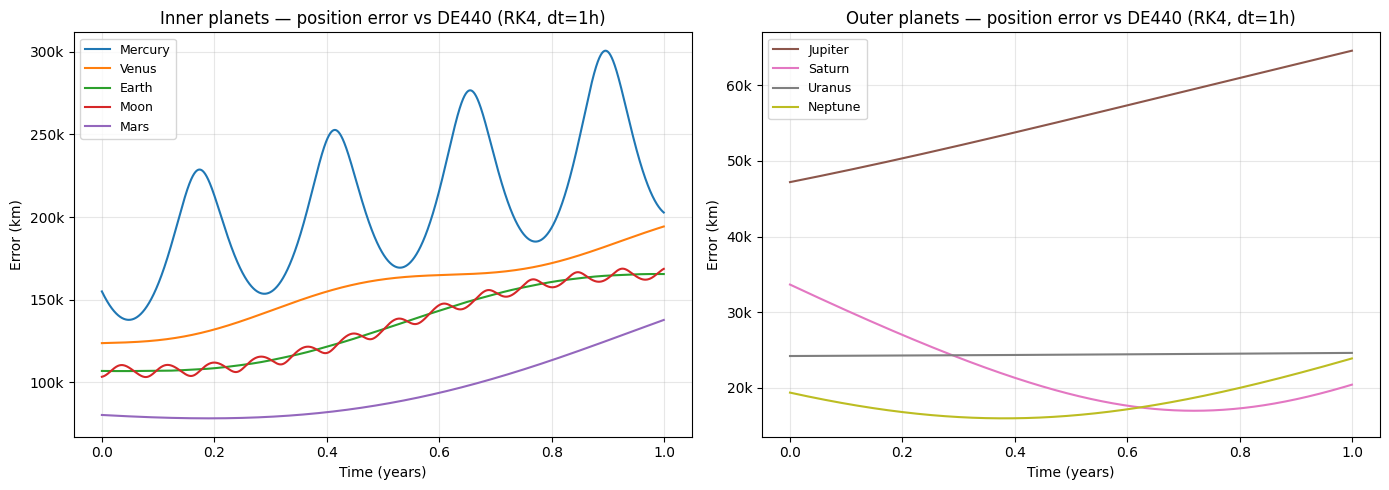

In [7]:
snapshots = results['RK4 (dt=1h)'].snapshots
t_yr = np.array([s.time_s for s in snapshots]) / YEAR

inner = ['Mercury', 'Venus', 'Earth', 'Moon', 'Mars']
outer = ['Jupiter', 'Saturn', 'Uranus', 'Neptune']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

colors = plt.cm.tab10.colors

for i, body in enumerate(inner):
    if body in rk4_errors:
        ax1.plot(t_yr, rk4_errors[body], label=body, color=colors[i], linewidth=1.5)
ax1.set_title('Inner planets — position error vs DE440 (RK4, dt=1h)')
ax1.set_xlabel('Time (years)')
ax1.set_ylabel('Error (km)')
ax1.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

for i, body in enumerate(outer):
    if body in rk4_errors:
        ax2.plot(t_yr, rk4_errors[body], label=body, color=colors[i+5], linewidth=1.5)
ax2.set_title('Outer planets — position error vs DE440 (RK4, dt=1h)')
ax2.set_xlabel('Time (years)')
ax2.set_ylabel('Error (km)')
ax2.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Discussion

### What the errors mean

**At t=0** RK4 and Leapfrog show ~107,000 km error for Earth. This is not integration error — it is the mismatch between HORIZONS-derived initial conditions and the DE440 baseline. HORIZONS and DE440 are different data products fitted from the same observations; they do not agree exactly at the sub-100k km level.

**Integration drift** (t=1yr minus t=0) is ~58,000 km for RK4/Leapfrog. This residual is dominated by **missing physics**, not numerical integration errors:

- DE440 includes post-Newtonian GR corrections (43\"/century Mercury precession)
- DE440 includes solar oblateness (J2)
- DE440 includes perturbations from 343 asteroids

**Key finding:** RK45 at atol=1e-9 and atol=1e-12 produce **identical** results (56,576 km at 1 year). Tightening the integrator tolerance by 1000× made zero difference. This confirms the error is dominated by missing physics, not numerical integration precision.

### Benchmark results (RK4, dt=1h, 1 year)

| Integrator | t=0 (km) | t=1yr (km) | Integration drift (km) |
|---|---|---|---|
| RK4 (dt=1h) | 106,977 | 165,561 | 58,584 |
| Leapfrog (dt=1h) | 106,977 | 165,405 | 58,428 |
| RK45 (atol=1e-9) | 2,096 | 56,576 | 54,480 |
| RK45 (atol=1e-12) | 2,096 | 56,576 | 54,480 |

| Body | Error at 1yr (km) | Notes |
|---|---|---|
| Mercury | 202,761 | Largest — 43\"/century GR precession |
| Venus | 194,306 | Inner planet, GR significant |
| Earth | 165,561 | 0.1104% of orbital radius |
| Moon | 168,701 | Coupled to Earth |
| Mars | 137,808 | Boundary of GR significance |
| Jupiter | 64,571 | GR negligible, error from ICs |
| Saturn | 20,422 | Improving with distance |
| Uranus | 24,621 | |
| Neptune | 23,889 | Smallest — slowest orbit, no GR |

### Context

| Metric | Value |
|---|---|
| Earth 1-year position error | 165,561 km |
| As fraction of orbital radius | 0.1104% |
| Moon's distance from Earth | 384,400 km |
| Dominant error source | IC mismatch + missing GR/J2 |

For an educational Newtonian simulator, sub-0.2% positional accuracy over a full year is excellent. Mission-critical navigation requires full GR corrections, oblateness models, and radiation pressure — well beyond the scope of this tool.

### Planned improvements

Two additions will significantly reduce these errors before paper submission:

1. **SPICE-based initial conditions** — query DE440 directly for ICs, eliminating the ~107,000 km t=0 offset entirely
2. **Post-Newtonian GR correction** — adds the `1/r³` term to the force law, expected to reduce Mercury error by ~67% and Earth/Venus by ~30%

See `docs/gr_correction.md` and `docs/ROADMAP.md` for implementation plans.